# Fine-Tuning Vision Transformer (ViT) for Bean Leaf Disease Classification

The goal of this project is to:


> Adapt a pretrained Vision Transformer (ViT) model to classify bean leaf images into three categories:

 - angular_leaf_spot
 - bean_rust
 - healthy

Instead of training a model from scratch, we use a pretrained ViT model from Google via Hugging Face and fine-tune it on the Beans dataset.

# Why Do We Need Fine-Tuning?

The pretrained model:

`'google/vit-base-patch16-224'`

was trained on ImageNet, which contains 1000 general object classes like:

- dog
- cat
- car
- cucumber

So when we pass a bean leaf image, the model might predict something completely unrelated.

Because:

- It has never seen plant diseases before.

- Its classification layer outputs 1000 ImageNet classes.

So we must:

1. Replace the final classification layer.

2. Train the model on our specific dataset.

This is called Transfer Learning / Fine-Tuning.

In [1]:
pip install datasets

In [2]:
from datasets import load_dataset

ds = load_dataset('beans')
ds

# The dataset contains:
  # image_file_path
  # image
  # labels

# There are 3 labels:
  # angular_leaf_spot
  # bean_rust
  # healthy

# The dataset is already split into:
  # train
  # validation
  # test

# This is important because:
# Training set → model learns
# Validation set → monitor performance
# Test set → final evaluation

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})

In [3]:
ex = ds['train'][450]
ex

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/bean_rust/bean_rust_train.193.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 1}

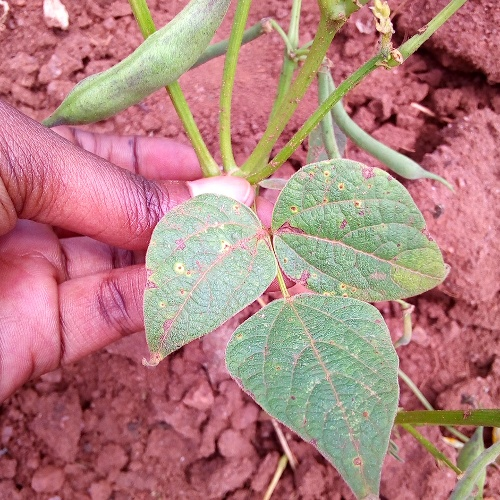

In [4]:
image = ex['image']
image

In [5]:
labels = ds['train'].features['labels']
labels

ClassLabel(names=['angular_leaf_spot', 'bean_rust', 'healthy'])

In [6]:
labels.int2str(ex['labels'])

'bean_rust'

In [7]:
from transformers import ViTForImageClassification, ViTImageProcessor


model_name_or_path = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_name_or_path)

# This processor ensures images are transformed exactly like during ViT pretraining.

# It performs:
# 1️⃣ Resize → 224 × 224
# 2️⃣ Rescale → divide pixel values by 255
# 3️⃣ Normalize → (x − mean) / std

# Why?
# Because the model expects input in a specific numerical distribution.
# If we don’t match that distribution:
  # Model performance drops drastically.

In [8]:
processor

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [9]:
# Loading Classification Model
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

# This loads pretrained ViT trained on ImageNet.
# But ImageNet has 1000 classes.
# Our dataset has only 3 classes.
# That is why it misclassifies.

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [10]:
# Passing Image Through Model
inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs.pixel_values
pixel_values
# The processor:
# Resizes
# Rescales
# Normalizes
# Converts to tensor

tensor([[[[ 0.8902,  0.7333,  0.6706,  ...,  0.2392,  0.1843,  0.4118],
          [ 0.8980,  0.9529,  0.9529,  ...,  0.2784,  0.2706,  0.4745],
          [ 0.3569,  0.6549,  0.9686,  ...,  0.4039,  0.3961,  0.5294],
          ...,
          [ 0.3569,  0.2235,  0.2000,  ...,  0.4824,  0.3882,  0.2000],
          [ 0.2784,  0.1765,  0.2000,  ...,  0.4588,  0.5216,  0.5608],
          [ 0.2314,  0.2235,  0.2078,  ...,  0.5765,  0.5059,  0.5922]],

         [[ 0.6706,  0.3804,  0.1843,  ..., -0.3961, -0.4667, -0.2471],
          [ 0.6078,  0.6706,  0.7020,  ..., -0.3569, -0.3725, -0.1686],
          [-0.2314,  0.1922,  0.7490,  ..., -0.2549, -0.2471, -0.1137],
          ...,
          [-0.2235, -0.3490, -0.3647,  ..., -0.0902, -0.2157, -0.4039],
          [-0.2863, -0.3882, -0.3725,  ..., -0.1451, -0.0824, -0.0118],
          [-0.3333, -0.3490, -0.3725,  ..., -0.0353, -0.0980,  0.0431]],

         [[ 0.7176,  0.4588,  0.2863,  ..., -0.2784, -0.3569, -0.1451],
          [ 0.6471,  0.7098,  

In [11]:
import torch

with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits
  # logits = raw prediction scores (before softmax).

prediction = logits.argmax(-1)
print("Predicted class:", model.config.id2label[prediction.item()])

Predicted class: cucumber, cuke


In [12]:
def process_example(example):
    inputs = processor(example['image'], return_tensors='pt')
    inputs['labels'] = example['labels']
    return inputs

In [13]:
process_example(ds['train'][0])

{'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255],
          [-0

In [14]:
def transform(example_batch):
    inputs = processor([x for x in example_batch['image']], return_tensors='pt')

    inputs['labels'] = example_batch['labels']
    return inputs

In [15]:
prepared_ds = ds.with_transform(transform)

In [16]:
prepared_ds['train'][0:2]

{'pixel_values': tensor([[[[-0.5686, -0.5686, -0.5608,  ..., -0.0275,  0.1843, -0.2471],
          [-0.6078, -0.6000, -0.5765,  ..., -0.0353, -0.0196, -0.2627],
          [-0.6314, -0.6314, -0.6078,  ..., -0.2314, -0.3647, -0.2235],
          ...,
          [-0.5373, -0.5529, -0.5843,  ..., -0.0824, -0.0431, -0.0902],
          [-0.5608, -0.5765, -0.5843,  ...,  0.3098,  0.1843,  0.1294],
          [-0.5843, -0.5922, -0.6078,  ...,  0.2627,  0.1608,  0.2000]],

         [[-0.7098, -0.7098, -0.7490,  ..., -0.3725, -0.1608, -0.6000],
          [-0.7333, -0.7333, -0.7569,  ..., -0.3647, -0.3255, -0.5686],
          [-0.7490, -0.7490, -0.7725,  ..., -0.5373, -0.6549, -0.5373],
          ...,
          [-0.7725, -0.7804, -0.8196,  ..., -0.2235, -0.0353,  0.0824],
          [-0.7961, -0.8118, -0.8118,  ...,  0.1922,  0.3098,  0.3725],
          [-0.8196, -0.8196, -0.8275,  ...,  0.0824,  0.2784,  0.3961]],

         [[-0.9922, -0.9922, -1.0000,  ..., -0.5451, -0.3569, -0.7255],
          [-0

In [17]:
import torch

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])
    }

In [18]:
pip install evaluate

In [19]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

In [20]:
from transformers import ViTForImageClassification

labels = ds['train'].features['labels'].names

model = ViTForImageClassification.from_pretrained(
    model_name_or_path,
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)}
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [22]:
!pip uninstall transformers -y
!pip install transformers --no-cache-dir

Found existing installation: transformers 5.5.0
Uninstalling transformers-5.5.0:
  Successfully uninstalled transformers-5.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.5 MB/s eta 0:00:00


In [23]:
from transformers import TrainingArguments, IntervalStrategy

training_args = TrainingArguments(
    output_dir="/content/gdrive/MyDrive/Computer_vision/Fine Tuning/ViT/Finetuned_model",
    per_device_train_batch_size=16,
    num_train_epochs=4,
    fp16=True,
    learning_rate=2e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="tensorboard",
    load_best_model_at_end=True,

    # Use strings for save_strategy
    eval_strategy=IntervalStrategy.STEPS,  # evaluation every N steps
    save_strategy="steps",                 # string, not enum
    logging_steps=10,
    save_steps=100,
    eval_steps=100
)

In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
)

In [26]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Step,Training Loss,Validation Loss,Accuracy
100,0.114983,0.068646,0.969925
200,0.048005,0.072058,0.977444
260,0.014352,0.075802,0.977444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** train metrics *****
  epoch                    =         4.0
  total_flos               = 298497957GF
  train_loss               =      0.1153
  train_runtime            =  0:01:40.75
  train_samples_per_second =       41.05
  train_steps_per_second   =        2.58


In [28]:
from transformers import AutoModelForImageClassification, ViTImageProcessor

# Load fine-tuned model
model = AutoModelForImageClassification.from_pretrained(
    "/content/gdrive/MyDrive/Computer_vision/Fine Tuning/ViT/Finetuned_model"
)

feature_extractor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [29]:
class_labels = {0: "angular_leaf_spot", 1: "bean_rust", 2: "healthy"}

inputs = feature_extractor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class = logits.argmax(-1).item()

predicted_label = class_labels.get(predicted_class, "Unknown class")

print(f"Predicted class: {predicted_class} - {predicted_label}")

Predicted class: 1 - bean_rust


In [30]:
test_dir = "/content/gdrive/MyDrive/Computer_vision/Fine Tuning/ViT/test.jpg"

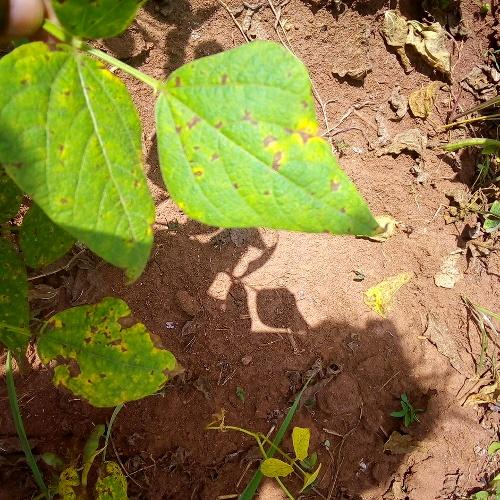

In [34]:
from PIL import Image

image = Image.open(test_dir)
image


In [35]:

class_labels = {0: "angular_leaf_spot", 1: "bean_rust", 2: "healthy"}

inputs = feature_extractor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

predicted_class = logits.argmax(-1).item()

predicted_label = class_labels.get(predicted_class, "Unknown class")

print(f"Predicted class: {predicted_class} - {predicted_label}")

Predicted class: 0 - angular_leaf_spot
